# Explore CelebAMask-HQ


In [1]:
from pathlib import Path

import pandas as pd
from PIL import Image

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate the project root from the current notebook session.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASET_ROOT = PROJECT_ROOT / 'backend' / 'data' / 'raw' / 'celebamask_hq'
IMAGE_ROOT = DATASET_ROOT / 'CelebA-HQ-img'
MASK_ROOT = DATASET_ROOT / 'CelebAMask-HQ-mask-anno'

print('Dataset root exists:', DATASET_ROOT.exists())
print('Image root exists:', IMAGE_ROOT.exists())
print('Mask root exists:', MASK_ROOT.exists())


Dataset root exists: True
Image root exists: True
Mask root exists: True


In [2]:
top_level_items = sorted(path.name for path in DATASET_ROOT.iterdir())
pd.DataFrame({'name': top_level_items})


,name
0,.DS_Store
1,CelebA-HQ-img
2,CelebA-HQ-to-CelebA-mapping.txt
3,CelebAMask-HQ-attribute-anno.txt
4,CelebAMask-HQ-mask-anno
5,CelebAMask-HQ-pose-anno.txt
6,README.txt


In [3]:
image_paths = sorted(IMAGE_ROOT.glob('*.jpg'))
hair_mask_paths = sorted(MASK_ROOT.rglob('*_hair.png'))
matched_image_count = sum((IMAGE_ROOT / f"{int(mask_path.stem.split('_')[0])}.jpg").exists() for mask_path in hair_mask_paths)

pd.Series(
    {
        'hq_image_count': len(image_paths),
        'hair_mask_count': len(hair_mask_paths),
        'matched_image_count': matched_image_count,
        'mask_folders': len([path for path in MASK_ROOT.iterdir() if path.is_dir()]),
    }
)


hq_image_count         30000
hair_mask_count        29300
matched_image_count    29300
mask_folders              15
dtype: int64

In [4]:
attribute_path = DATASET_ROOT / 'CelebAMask-HQ-attribute-anno.txt'
attribute_df = pd.read_csv(attribute_path, sep='\s+', skiprows=1)
attribute_df.head()


,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0.jpg,-1,1,1,1,-1,-1,1,-1,-1,-1,...,-1,1,-1,1,-1,-1,1,-1,-1,1
1.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,1,...,-1,1,-1,1,-1,-1,1,-1,-1,1
2.jpg,-1,-1,1,1,-1,-1,1,-1,-1,-1,...,-1,1,-1,1,1,-1,1,-1,-1,1
3.jpg,-1,-1,1,-1,-1,-1,-1,1,1,-1,...,-1,1,-1,1,-1,-1,1,-1,-1,1
4.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,1,-1,1,-1,-1,-1,-1,1


In [5]:
hair_related_columns = [
    column
    for column in attribute_df.columns
    if 'Hair' in column or 'Bangs' in column or 'Bald' in column or 'Receding' in column
]
attribute_df[hair_related_columns].replace({-1: 0, 1: 1}).mean().sort_values(ascending=False)


Wavy_Hair            0.357433
Brown_Hair           0.230833
Black_Hair           0.219733
Straight_Hair        0.214800
Bangs                0.180833
Blond_Hair           0.170867
Receding_Hairline    0.084333
Gray_Hair            0.041400
Bald                 0.023733
dtype: float64

Sample image: 0.jpg (1024, 1024)
Sample mask: 00000_hair.png (512, 512)


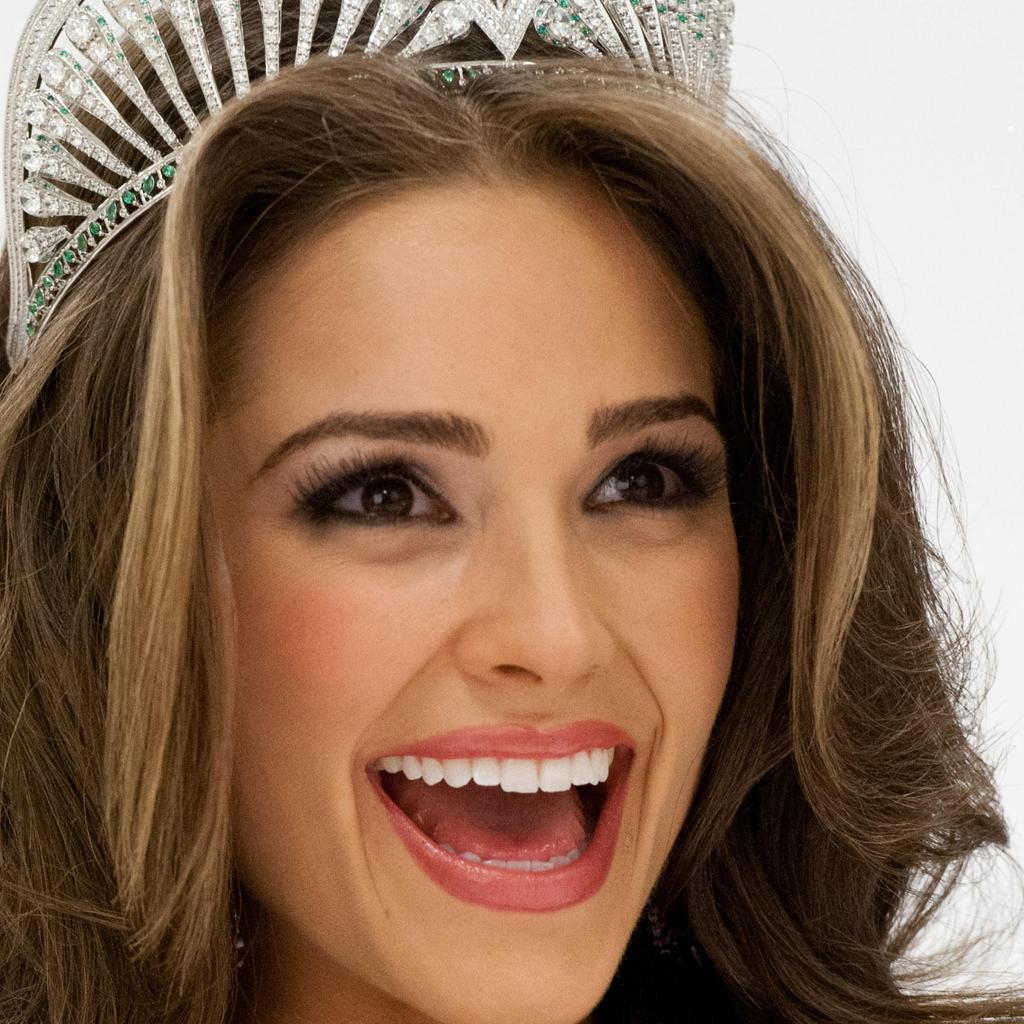

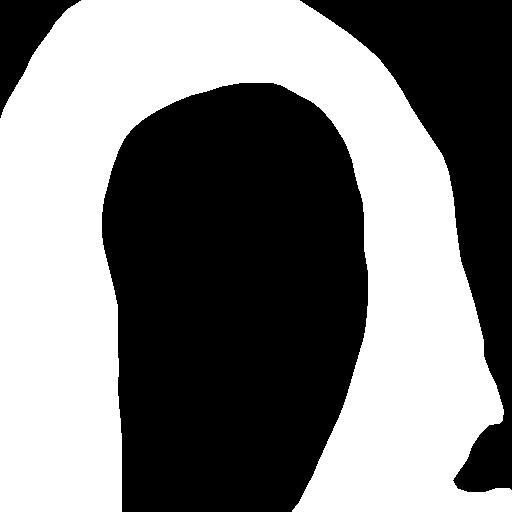

In [6]:
if hair_mask_paths:
    sample_mask_path = hair_mask_paths[0]
    sample_image_path = IMAGE_ROOT / f"{int(sample_mask_path.stem.split('_')[0])}.jpg"

    with Image.open(sample_image_path) as image, Image.open(sample_mask_path) as mask:
        print('Sample image:', sample_image_path.name, image.size)
        print('Sample mask:', sample_mask_path.name, mask.size)
        display(image)
        display(mask)
else:
    print('No hair masks were found under', MASK_ROOT)


In [7]:
folder_counts = pd.DataFrame(
    [
        {'folder': folder.name, 'hair_masks': len(list(folder.glob('*_hair.png')))}
        for folder in sorted(path for path in MASK_ROOT.iterdir() if path.is_dir())
    ]
)
folder_counts.head()


,folder,hair_masks
0,0,1979
1,1,1975
2,10,1942
3,11,1957
4,12,1943


## Takeaways

- `CelebAMask-HQ` is the direct source for Version 1 segmentation records.
- The raw dataset already contains enough image-mask pairs to build a first training manifest.
- The attribute file is useful as supporting metadata, but the core segmentation path is image plus `*_hair.png` mask pairing.
